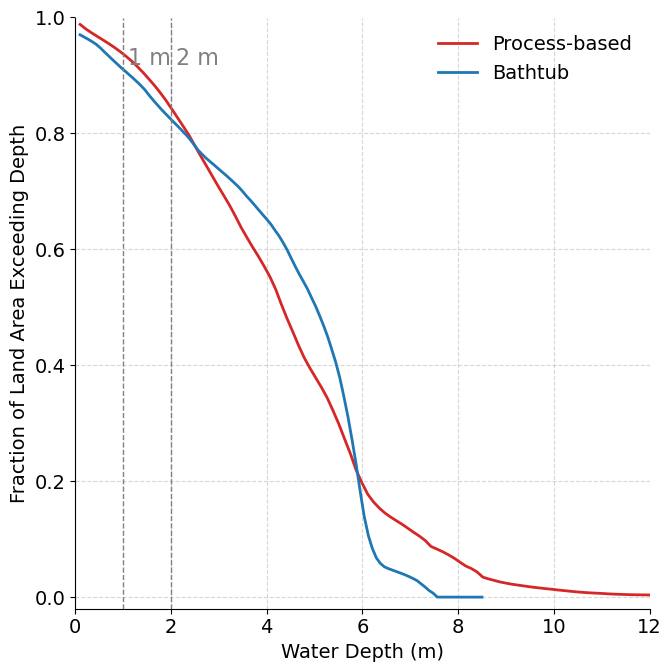

In [4]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ------------------ FONT SIZE SETTINGS ------------------
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})
# ---------------------------------------------------------

# ------------------ USER INPUTS ------------------
# Use keys EXACTLY as below for color mapping
raster_paths = {
    "Process-based": r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif",
    "Bathtub":       r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif",
}
boundary_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Exceedance settings
FLOOD_PRESENCE_THRESH = 0.1      # presence threshold (used only if DENOMINATOR == "flooded")
DENOMINATOR = "land"             # "land" or "flooded"
DEPTH_CAP = None                 # e.g., 12.0 to cap
N_THRESH = 100
MANUAL_THRESHOLDS = [0.1, 1.0, 2.0]
SMOOTH_WINDOW = 8
XMAX = 12.0                      # x-axis upper limit
# -------------------------------------------------

# Color mapping: Process-based RED, Bathtub BLUE
SERIES_COLOR = {
    "Process-based": "#d62728",  # red
    "Bathtub":       "#1f77b4",  # blue
}

def load_clip_depth(raster_path, boundary_gdf):
    """Read raster, clip to boundary, clean negatives/NoData, compute cell area and land area."""
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)

        # Clip raster to boundary
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        depth = out_img[0].astype("float64")
        nodata = src.nodata

    # Clean values
    if nodata is not None:
        depth = np.where(depth == nodata, np.nan, depth)
    depth = np.where(depth < 0, np.nan, depth)
    if DEPTH_CAP is not None:
        depth = np.where(depth > DEPTH_CAP, np.nan, depth)

    depth_ma = ma.masked_invalid(depth)

    # Pixel area (assumes projected CRS in meters)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Land area from boundary geometry (in raster CRS units)
    land_area_m2 = boundary_proj.geometry.area.sum()

    return depth_ma, cell_area_m2, land_area_m2

def smooth_series(y, window=7):
    if window is None or window < 3 or window % 2 == 0:
        return y
    y = np.asarray(y, dtype=float)
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    ys = np.convolve(ypad, kernel, mode="valid")
    return ys

# Load boundary (zipped shapefile path works with fiona/gpd)
boundary = gpd.read_file(boundary_path)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Define it (e.g., EPSG:32614) before running.")

curves = []
fig, ax = plt.subplots(figsize=(7, 7))

for label, rp_path in raster_paths.items():
    depth_ma, cell_area_m2, land_area_m2 = load_clip_depth(rp_path, boundary)

    valid_vals = depth_ma.compressed()
    if valid_vals.size == 0:
        print(f"[WARN] No valid values after masking for: {label}")
        continue

    # Threshold range
    dmin = max(0.0, float(np.nanmin(valid_vals)))
    if FLOOD_PRESENCE_THRESH is not None:
        dmin = max(dmin, FLOOD_PRESENCE_THRESH)
    dmax_obs = float(np.nanmax(valid_vals))
    dmax = min(dmax_obs, DEPTH_CAP) if DEPTH_CAP is not None else dmax_obs
    if dmax <= dmin:
        print(f"[WARN] dmax <= dmin for: {label} (dmin={dmin:.3f}, dmax={dmax:.3f})")
        continue

    # Build thresholds (include manual)
    thr_auto = np.linspace(dmin, min(dmax, XMAX), N_THRESH)
    thresholds = np.unique(np.clip(np.array(list(thr_auto) + MANUAL_THRESHOLDS), dmin, min(dmax, XMAX)))

    # Denominator area
    flooded_presence_mask = (depth_ma >= FLOOD_PRESENCE_THRESH)
    flooded_area_m2 = flooded_presence_mask.filled(False).sum() * cell_area_m2
    denom_area_m2 = land_area_m2 if DENOMINATOR == "land" else flooded_area_m2
    if denom_area_m2 == 0:
        print(f"[WARN] Zero denominator for: {label}")
        continue

    # Fraction of area exceeding each threshold
    frac = []
    for t in thresholds:
        exceed_mask = (depth_ma >= t)
        exceed_area_m2 = exceed_mask.filled(False).sum() * cell_area_m2
        frac.append(exceed_area_m2 / denom_area_m2)

    # Smooth, clip to [0,1]
    frac = np.clip(smooth_series(frac, window=SMOOTH_WINDOW), 0.0, 1.0)

    # Store & plot
    df = pd.DataFrame({
        "scenario": label,
        "threshold_m": thresholds,
        f"fraction_exceeding_{DENOMINATOR}": frac
    })
    curves.append(df)

    ax.plot(thresholds, frac, label=label, linewidth=2,
            color=SERIES_COLOR.get(label, None))

# ---- Presentation tweaks ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel("Fraction of Land Area Exceeding Depth" if DENOMINATOR == "land"
              else "Fraction of Flooded Area Exceeding Depth")

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, XMAX)
ax.set_ylim(-0.02, 1)

# Reference lines at 1 m and 2 m
for d in [1.0, 2.0]:
    ax.axvline(x=d, color='gray', linestyle='--', linewidth=1)
    ax.text(d + 0.1, 0.95, f"{int(d)} m", transform=ax.get_xaxis_transform(),
            va='top', fontsize=16, color='gray')

ax.legend(frameon=False, ncol=1)
plt.tight_layout()

# Save CSV with both curves
if curves:
    df_all = pd.concat(curves, ignore_index=True)
    out_csv = Path.cwd() / f"depth_exceedance_curves_process_vs_bathtub_{DENOMINATOR}.csv"
    df_all.to_csv(out_csv, index=False)
    # print(f"Saved exceedance data to: {out_csv}")

plt.show()
